In [1]:
# improved_train_and_eval_finetune.py
import os, random, math, time
import numpy as np
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import albumentations as A
from albumentations.pytorch import ToTensorV2
from pycocotools.coco import COCO

from torchvision.models.segmentation import (
    deeplabv3_resnet101, DeepLabV3_ResNet101_Weights
)

# ----------------------
# Config
# ----------------------
DATA_DIR = r"C:/Users/rahul/Downloads/coco"
ANNOTATIONS = os.path.join(DATA_DIR, "annotations", "instances_val2017.json")
IMAGES_DIR = os.path.join(DATA_DIR, "val2017")

SAVE_PATH = r"C:\Users\rahul\Downloads\infosys project\deeplabv3_resnet101_finetuned.pth"
PREV_MODEL_PATH = r"C:\Users\rahul\Downloads\infosys project\deeplabv3_best_safe.pth"  # old resnet50 weights

INPUT_SIZE = 512
BATCH_SIZE = 2
ACCUM_ITERS = 1
NUM_EPOCHS = 30
NUM_WORKERS = 0
PATIENCE = 8
LR = 1e-5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ----------------------
# Dataset
# ----------------------
class COCODataset(Dataset):
    def __init__(self, root, annFile, transforms=None):
        self.root = root
        self.coco = COCO(annFile)
        self.ids = list(self.coco.imgs.keys())
        self.transforms = transforms

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.root, info['file_name'])
        img = np.array(Image.open(img_path).convert("RGB"))

        mask = np.zeros((info['height'], info['width']), dtype=np.uint8)
        for ann in self.coco.loadAnns(self.coco.getAnnIds(imgIds=img_id)):
            mask = np.maximum(mask, self.coco.annToMask(ann).astype(np.uint8))

        if self.transforms:
            augmented = self.transforms(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']

        return img, mask.long()

# ----------------------
# Transforms
# ----------------------
train_transforms = A.Compose([
    A.Resize(INPUT_SIZE, INPUT_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

val_transforms = A.Compose([
    A.Resize(INPUT_SIZE, INPUT_SIZE),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

# ----------------------
# Losses + metrics
# ----------------------
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        targets = targets.float()
        probs_flat = probs.view(probs.size(0), -1)
        targ_flat = targets.view(targets.size(0), -1)
        intersection = (probs_flat * targ_flat).sum(dim=1)
        dice = (2.*intersection + self.smooth) / (probs_flat.sum(dim=1) + targ_flat.sum(dim=1) + self.smooth)
        return 1.0 - dice.mean()

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.8, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction="none")
    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets.float())
        pt = torch.exp(-bce_loss)
        focal = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal.mean()

def combined_loss(outputs, masks):
    return 0.5 * DiceLoss()(outputs, masks) + 0.5 * FocalLoss()(outputs, masks)

def compute_batch_metrics(preds, masks, threshold=0.5):
    preds_bin = (preds > threshold).float()
    masks_f = masks.float()
    eps = 1e-6
    intersection = (preds_bin * masks_f).view(preds.size(0), -1).sum(dim=1)
    union = (preds_bin + masks_f).view(preds.size(0), -1).sum(dim=1) - intersection
    iou = (intersection + eps) / (union + eps)
    dice = (2*intersection + eps) / ((preds_bin.view(preds.size(0), -1).sum(dim=1) +
                                      masks_f.view(masks_f.size(0), -1).sum(dim=1)) + eps)
    acc = (preds_bin == masks_f).float().view(preds.size(0), -1).mean(dim=1)
    return iou.mean().item(), dice.mean().item(), acc.mean().item()

# ----------------------
# Train & Validate
# ----------------------
def train_model(model, train_loader, val_loader, device, save_path, epochs=NUM_EPOCHS):
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    best_iou = 0.0
    patience_counter = 0

    scaler = torch.amp.GradScaler("cuda") if device.type == "cuda" else None

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{epochs}")
        optimizer.zero_grad()
        for step, (imgs, masks) in pbar:
            imgs = imgs.to(device)
            masks = masks.to(device).unsqueeze(1)

            with torch.amp.autocast("cuda", enabled=(scaler is not None)):
                outputs = model(imgs)['out']
                loss = combined_loss(outputs, masks)

            if scaler:
                scaler.scale(loss).backward()
                if (step + 1) % ACCUM_ITERS == 0:
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad()
            else:
                loss.backward()
                if (step + 1) % ACCUM_ITERS == 0:
                    optimizer.step()
                    optimizer.zero_grad()

            running_loss += loss.item()
            pbar.set_postfix({"loss": loss.item()})

        # Validation
        model.eval()
        val_loss, val_iou, val_dice, val_acc = 0.0, 0.0, 0.0, 0.0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs = imgs.to(device)
                masks = masks.to(device).unsqueeze(1)
                with torch.amp.autocast("cuda", enabled=(scaler is not None)):
                    outputs = model(imgs)['out']
                    loss = combined_loss(outputs, masks)
                val_loss += loss.item()
                probs = torch.sigmoid(outputs)
                iou, dice, acc = compute_batch_metrics(probs, masks)
                val_iou += iou; val_dice += dice; val_acc += acc

        val_loss /= len(val_loader)
        val_iou /= len(val_loader)
        val_dice /= len(val_loader)
        val_acc /= len(val_loader)

        print(f"\nEpoch {epoch+1} | TrainLoss={running_loss/len(train_loader):.4f} "
              f"| ValLoss={val_loss:.4f} | IoU={val_iou:.4f} | Dice={val_dice:.4f} | Acc={val_acc:.4f}")

        scheduler.step()

        if val_iou > best_iou + 1e-4:
            best_iou = val_iou
            print(f"New best IoU {best_iou:.4f} -> saving model")
            torch.save(model.state_dict(), save_path)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("Early stopping.")
                break

    print("Training finished. Best IoU:", best_iou)
    return best_iou

# ----------------------
# Main
# ----------------------
if __name__ == "__main__":
    # Dataset
    full_dataset = COCODataset(IMAGES_DIR, ANNOTATIONS, transforms=train_transforms)
    train_n = int(0.8 * len(full_dataset))
    val_n = len(full_dataset) - train_n
    train_ds, val_ds = random_split(full_dataset, [train_n, val_n])
    val_ds.dataset.transforms = val_transforms

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    # Model
    model = deeplabv3_resnet101(weights=DeepLabV3_ResNet101_Weights.DEFAULT)
    model.classifier[4] = nn.Conv2d(256, 1, kernel_size=1)

    # load previous weights (fine-tuning)
    if os.path.exists(PREV_MODEL_PATH):
        print("Loading previous ResNet50 checkpoint for fine-tuning...")
        prev_weights = torch.load(PREV_MODEL_PATH, map_location="cpu")
        model.load_state_dict(prev_weights, strict=False)

    model.to(DEVICE)

    # Train
    best = train_model(model, train_loader, val_loader, DEVICE, SAVE_PATH, epochs=NUM_EPOCHS)


Device: cuda
loading annotations into memory...
Done (t=0.79s)
creating index...
index created!
Loading previous ResNet50 checkpoint for fine-tuning...


Epoch 1/30: 100%|██████████████████████████████████████████████████████| 2000/2000 [16:10<00:00,  2.06it/s, loss=0.196]



Epoch 1 | TrainLoss=0.2282 | ValLoss=0.2498 | IoU=0.6329 | Dice=0.7419 | Acc=0.8820
New best IoU 0.6329 -> saving model


Epoch 2/30: 100%|██████████████████████████████████████████████████████| 2000/2000 [15:30<00:00,  2.15it/s, loss=0.293]



Epoch 2 | TrainLoss=0.1835 | ValLoss=0.1913 | IoU=0.6830 | Dice=0.7819 | Acc=0.9040
New best IoU 0.6830 -> saving model


...


Epoch 19 | TrainLoss=0.0911 | ValLoss=0.1663 | IoU=0.7272 | Dice=0.8185 | Acc=0.9235


Epoch 20/30: 100%|████████████████████████████████████████████████████| 2000/2000 [15:03<00:00,  2.21it/s, loss=0.0921]



Epoch 20 | TrainLoss=0.0897 | ValLoss=0.1642 | IoU=0.7204 | Dice=0.8110 | Acc=0.9239


Epoch 21/30: 100%|████████████████████████████████████████████████████| 2000/2000 [15:05<00:00,  2.21it/s, loss=0.0593]



Epoch 21 | TrainLoss=0.0879 | ValLoss=0.1645 | IoU=0.7325 | Dice=0.8225 | Acc=0.9255
Early stopping.
Training finished. Best IoU: 0.7337777227759361


Device: cuda
loading annotations into memory...
Done (t=0.83s)
creating index...
index created!
[Image 1] Acc=0.9266, IoU=0.4638, Dice=0.6337


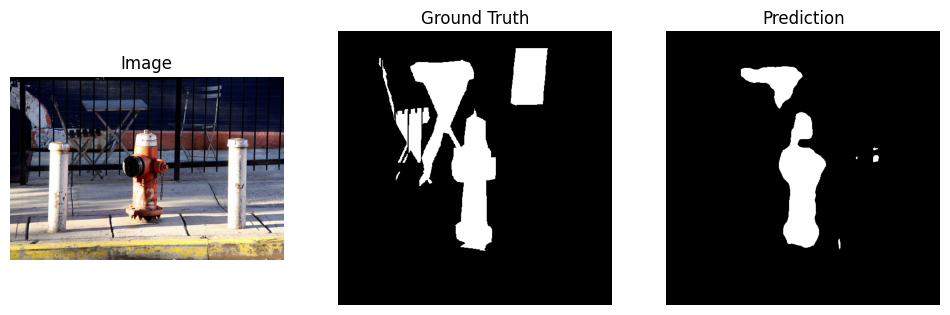

[Image 2] Acc=0.8983, IoU=0.8825, Dice=0.9376


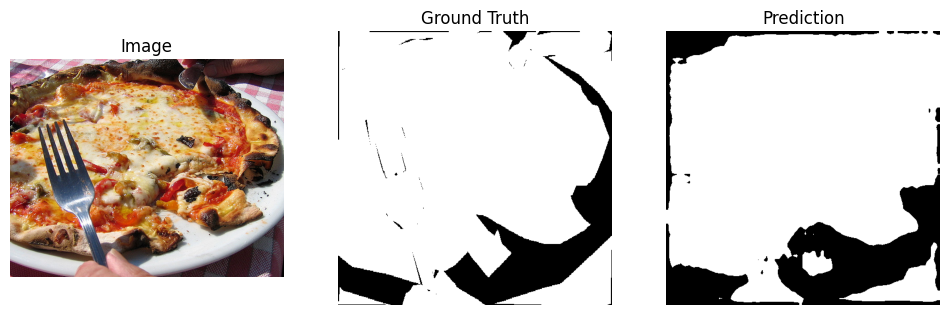

[Image 3] Acc=0.9960, IoU=0.9191, Dice=0.9578


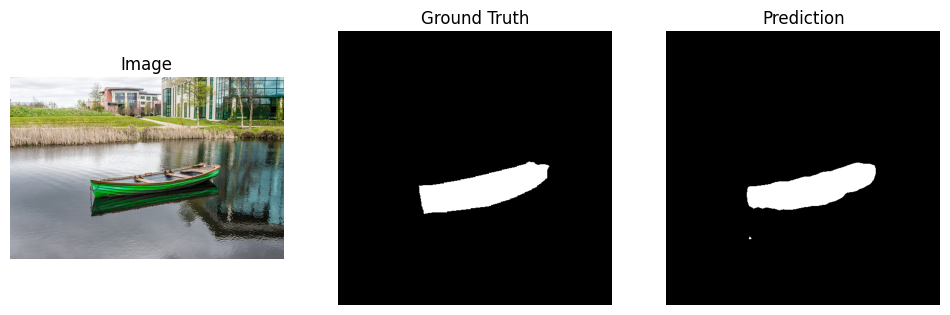

[Image 4] Acc=0.9965, IoU=0.4021, Dice=0.5736


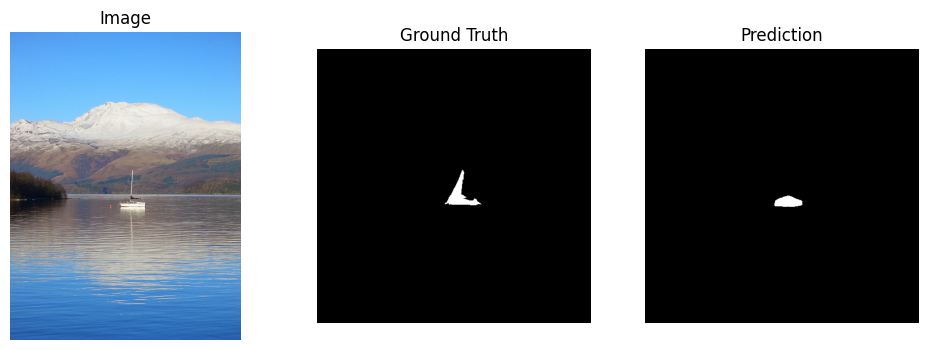

[Image 5] Acc=0.9137, IoU=0.7888, Dice=0.8819


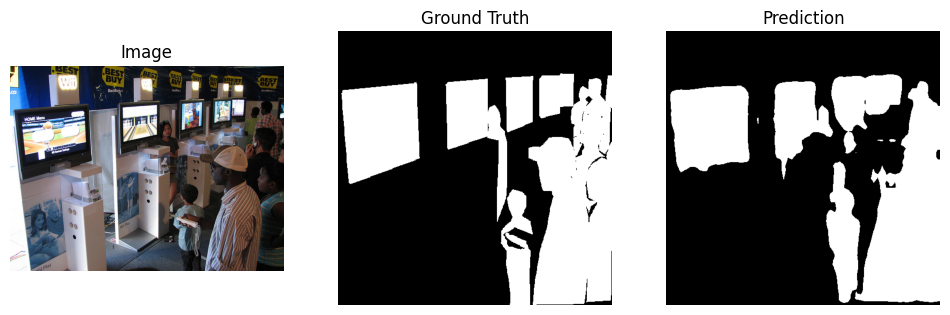

[Image 6] Acc=0.9675, IoU=0.6385, Dice=0.7794


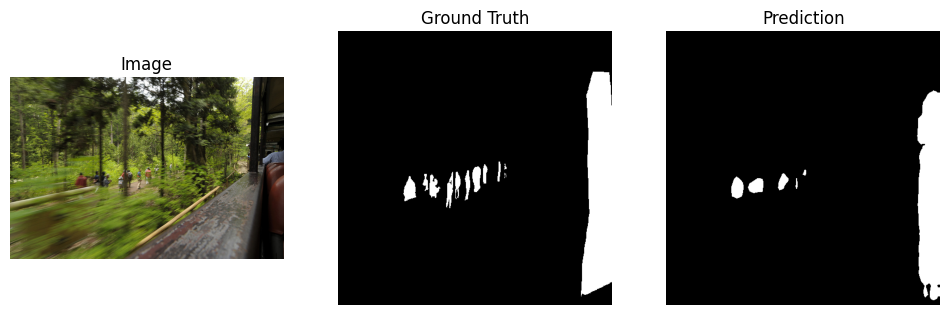

[Image 7] Acc=0.9830, IoU=0.8851, Dice=0.9390


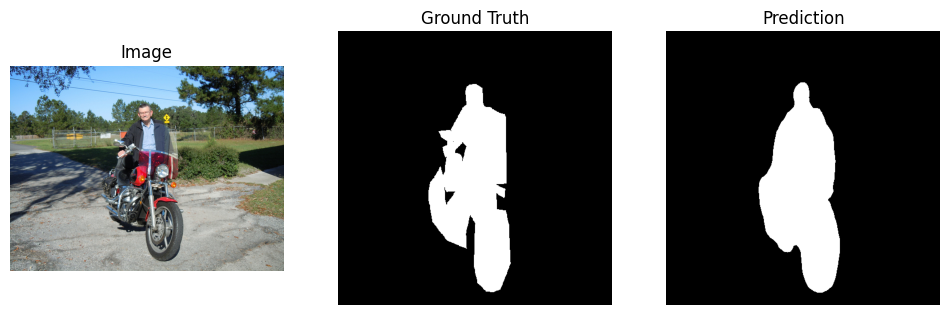

[Image 8] Acc=0.9116, IoU=0.7946, Dice=0.8855


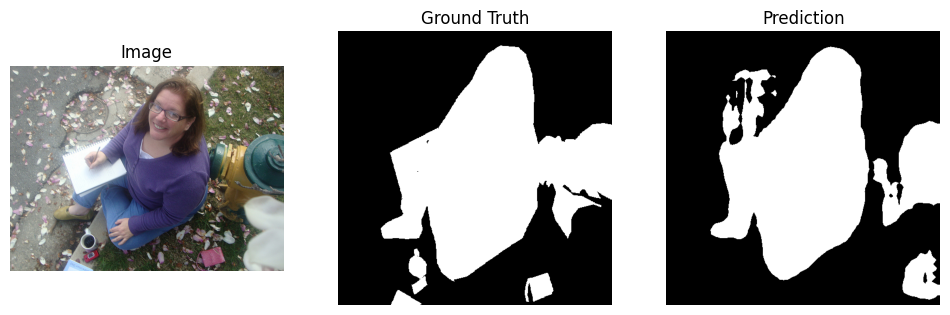

[Image 9] Acc=0.9690, IoU=0.9572, Dice=0.9781


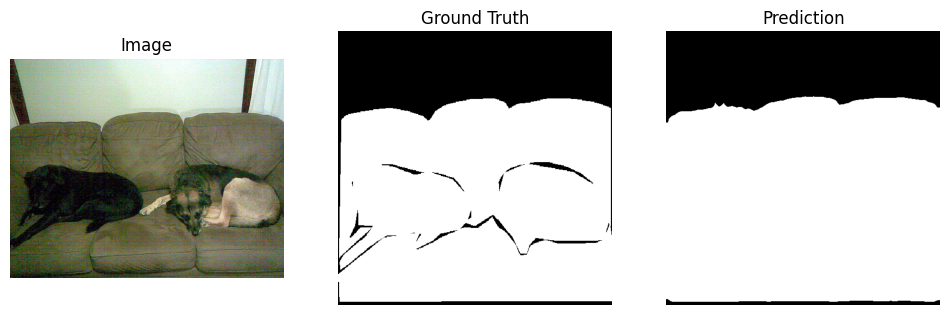

[Image 10] Acc=0.8313, IoU=0.7618, Dice=0.8648


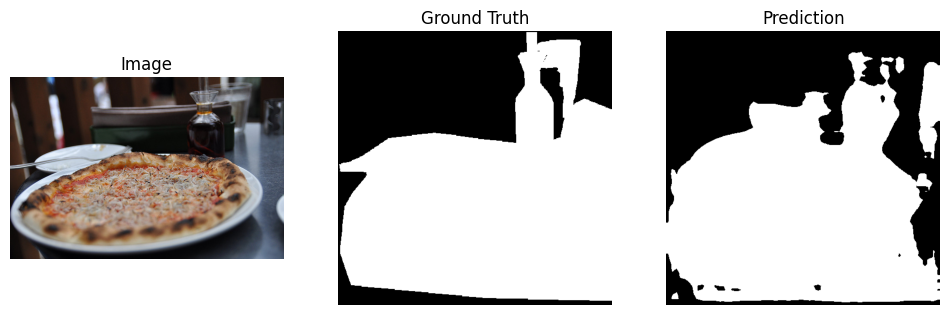

[Image 11] Acc=0.9810, IoU=0.8936, Dice=0.9438


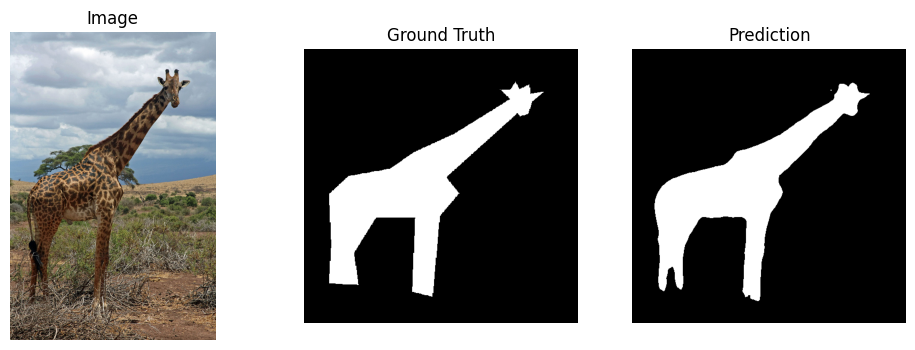

[Image 12] Acc=0.9386, IoU=0.8825, Dice=0.9376


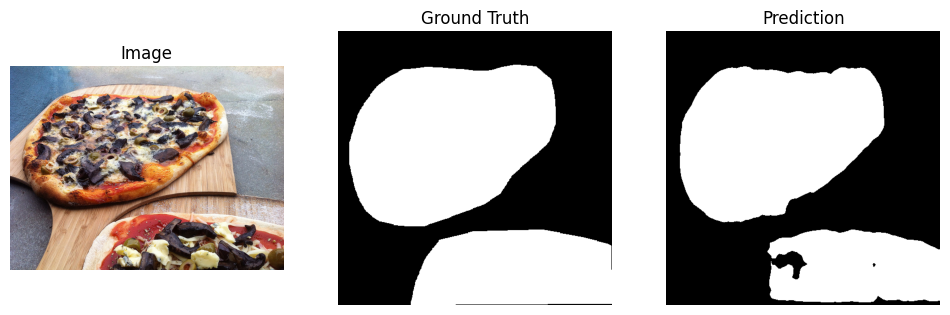

[Image 13] Acc=0.4812, IoU=0.4719, Dice=0.6412


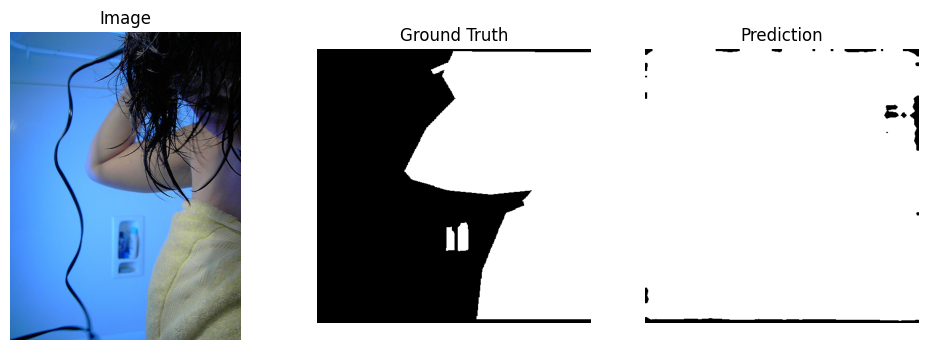

[Image 14] Acc=0.9274, IoU=0.6582, Dice=0.7939


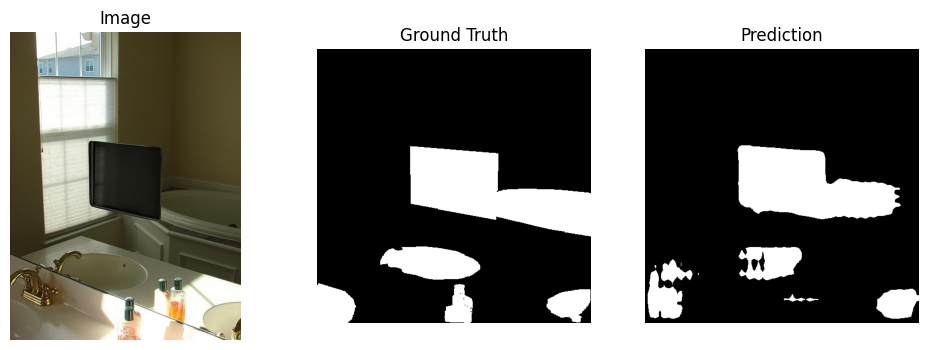

[Image 15] Acc=0.9737, IoU=0.7889, Dice=0.8820


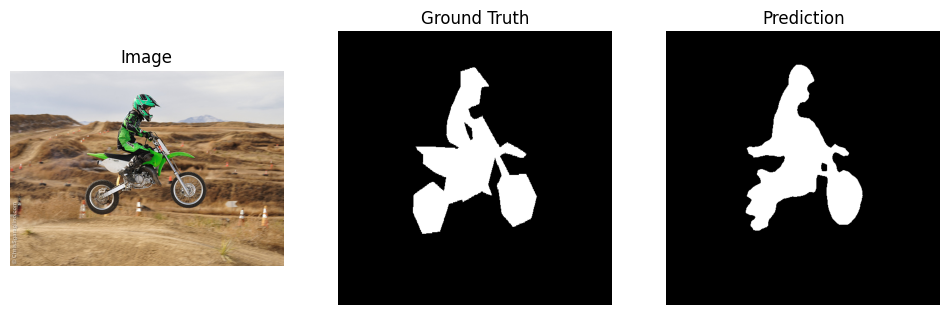

[Image 16] Acc=0.9157, IoU=0.8744, Dice=0.9330


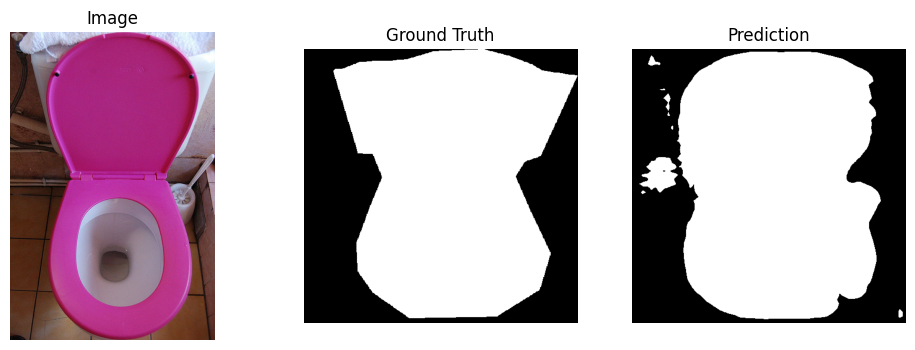

[Image 17] Acc=0.9727, IoU=0.9542, Dice=0.9766


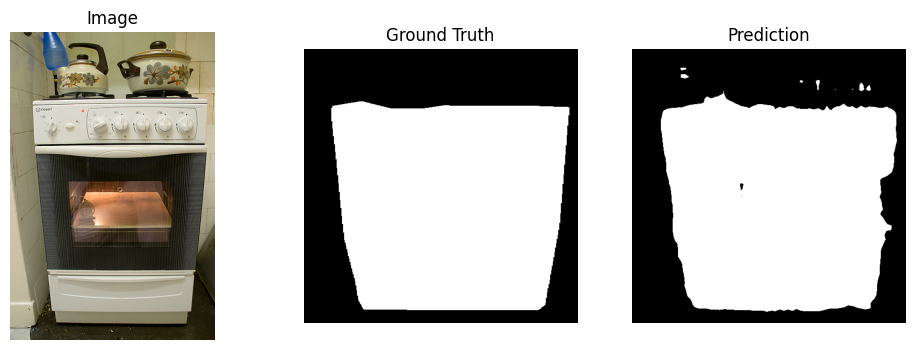

[Image 18] Acc=0.9143, IoU=0.8160, Dice=0.8987


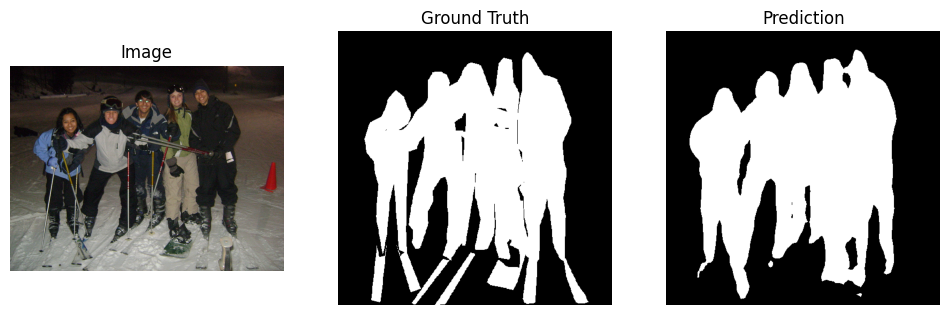

[Image 19] Acc=0.9700, IoU=0.7800, Dice=0.8764


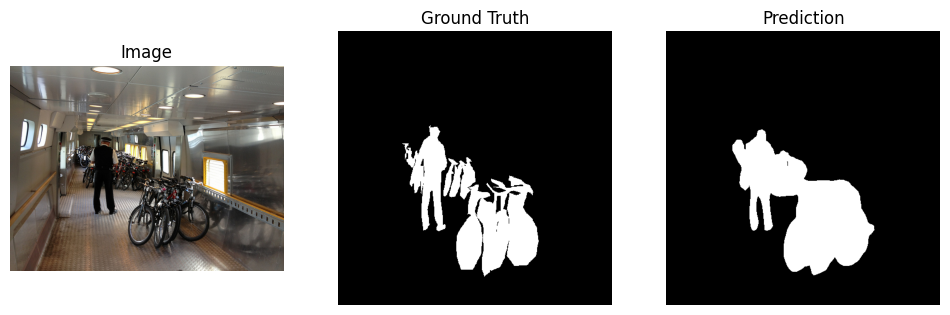

[Image 20] Acc=0.9820, IoU=0.8312, Dice=0.9078


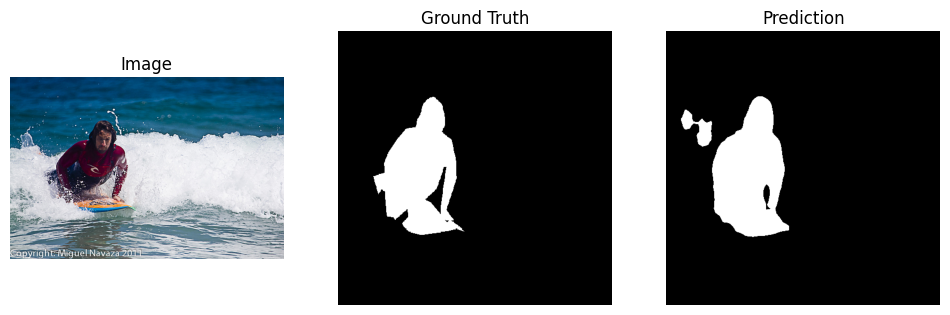

[Image 21] Acc=0.9341, IoU=0.9192, Dice=0.9579


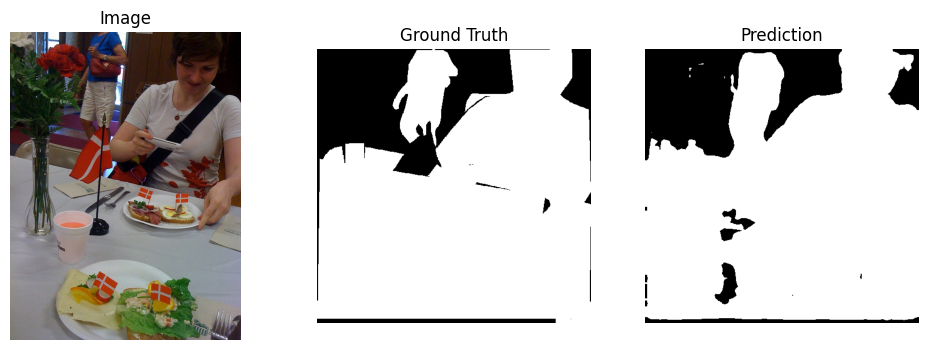

[Image 22] Acc=0.9729, IoU=0.9140, Dice=0.9551


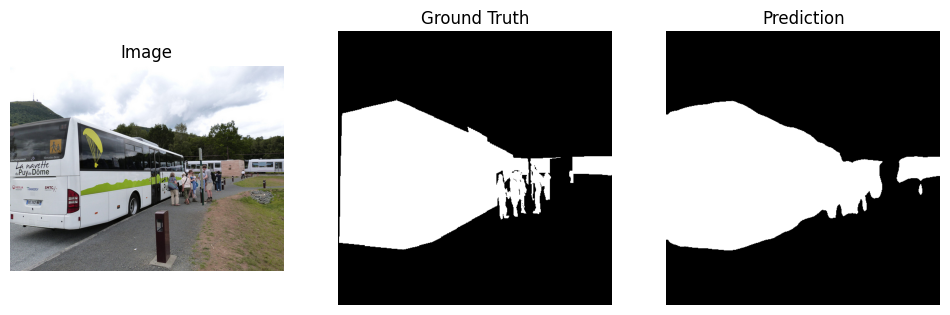

[Image 23] Acc=0.9786, IoU=0.9217, Dice=0.9593


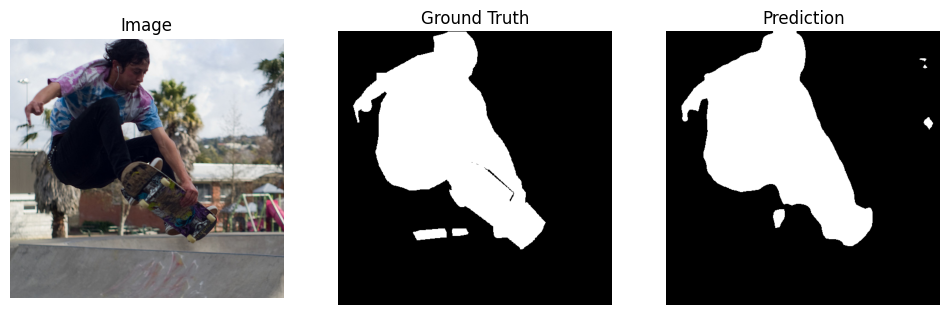

[Image 24] Acc=0.9488, IoU=0.9176, Dice=0.9570


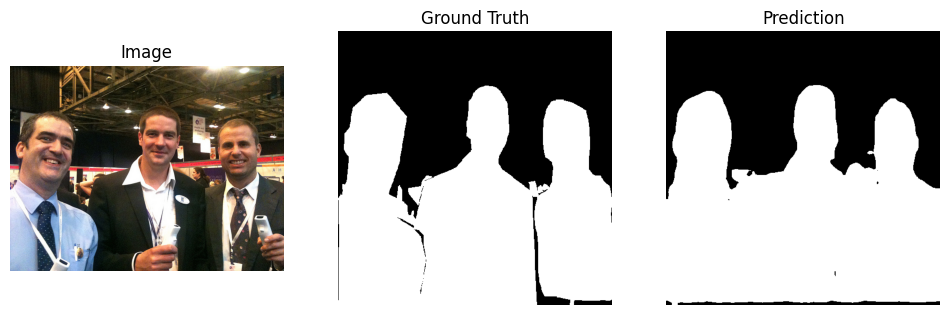

[Image 25] Acc=0.8994, IoU=0.8450, Dice=0.9160


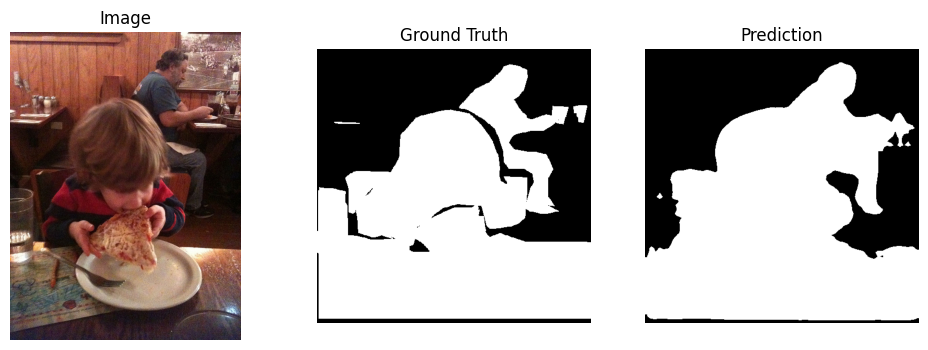

[Image 26] Acc=0.9283, IoU=0.9258, Dice=0.9615


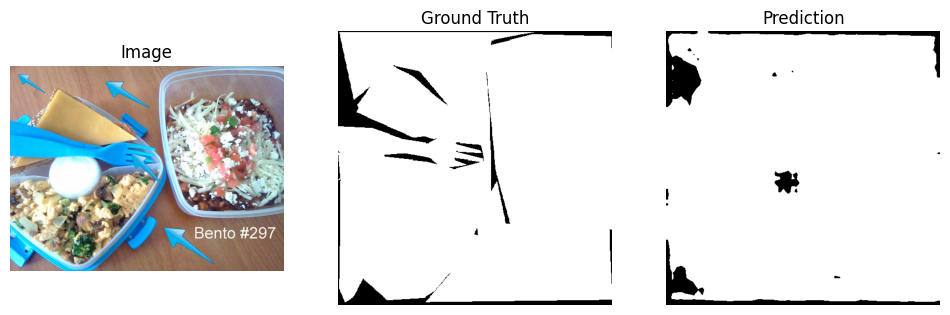

[Image 27] Acc=0.8044, IoU=0.7578, Dice=0.8622


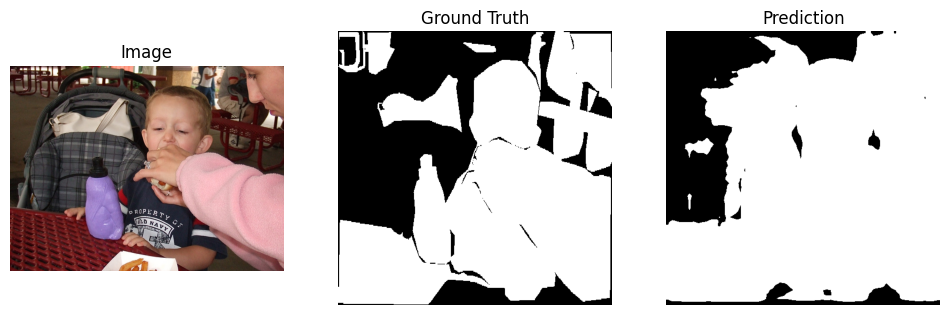

[Image 28] Acc=0.9869, IoU=0.7983, Dice=0.8878


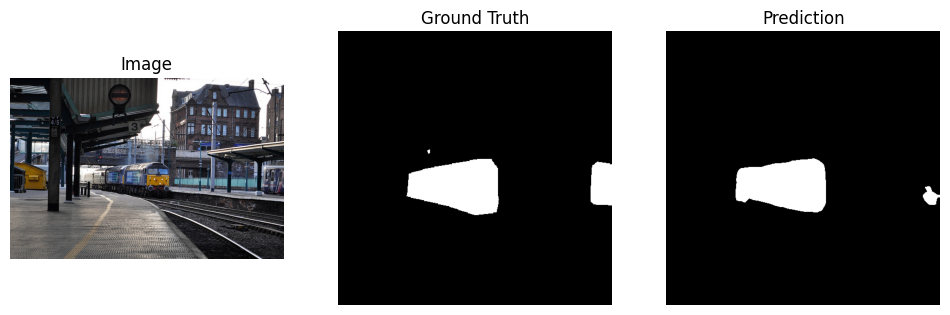

[Image 29] Acc=0.9650, IoU=0.8868, Dice=0.9400


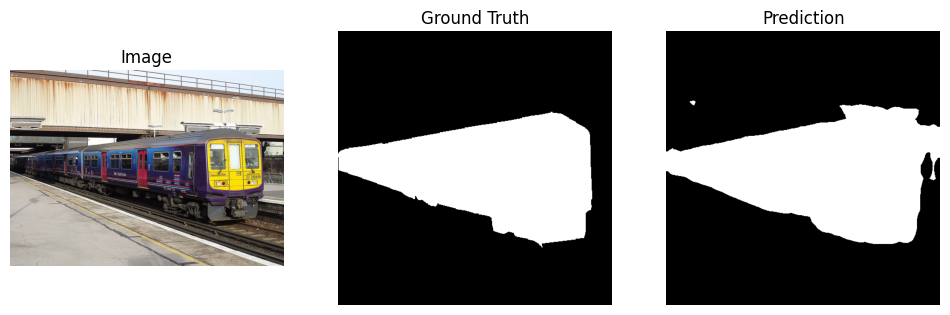

[Image 30] Acc=0.9703, IoU=0.9569, Dice=0.9780


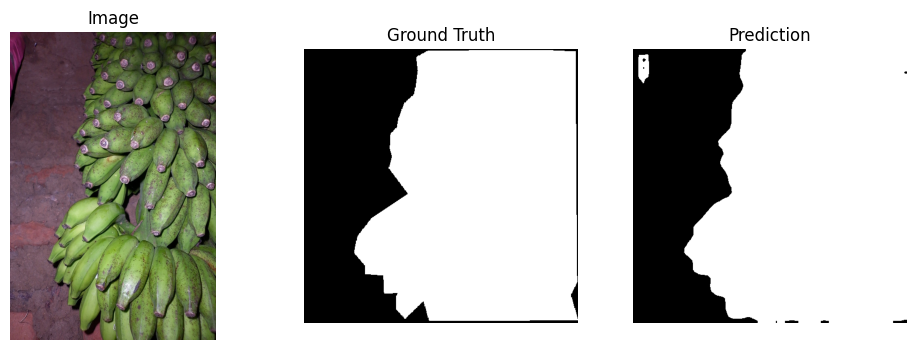


===== Evaluation on Random Samples =====
Pixel Accuracy: 0.9280
Mean IoU: 0.8096
Mean Dice Score: 0.8866


In [4]:
# evaluate_random_images.py
import os, random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from albumentations import Compose, Resize, Normalize
from albumentations.pytorch import ToTensorV2
from pycocotools.coco import COCO

from torchvision.models.segmentation import deeplabv3_resnet101

# ----------------------
# Config
# ----------------------
DATA_DIR = r"C:/Users/rahul/Downloads/coco"
ANNOTATIONS = os.path.join(DATA_DIR, "annotations", "instances_val2017.json")
IMAGES_DIR = os.path.join(DATA_DIR, "val2017")

SAVE_PATH = r"C:\Users\rahul\Downloads\infosys project\deeplabv3_resnet101_finetuned.pth"

INPUT_SIZE = 512
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ----------------------
# Transforms
# ----------------------
val_transforms = Compose([
    Resize(INPUT_SIZE, INPUT_SIZE),
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# ----------------------
# Metrics
# ----------------------
def compute_batch_metrics(preds, masks, threshold=0.5):
    preds_bin = (preds > threshold).float()
    masks_f = masks.float()
    eps = 1e-6
    intersection = (preds_bin * masks_f).view(preds.size(0), -1).sum(dim=1)
    union = (preds_bin + masks_f).view(preds.size(0), -1).sum(dim=1) - intersection
    iou = (intersection + eps) / (union + eps)
    dice = (2*intersection + eps) / (
        preds_bin.view(preds.size(0), -1).sum(dim=1) +
        masks_f.view(masks_f.size(0), -1).sum(dim=1) + eps
    )
    acc = (preds_bin == masks_f).float().view(preds.size(0), -1).mean(dim=1)
    return iou.mean().item(), dice.mean().item(), acc.mean().item()

# ----------------------
# Evaluation
# ----------------------
def evaluate_random_images(model, coco_ann, img_root, device, num=20, threshold=0.5):
    model.eval()
    img_ids = random.sample(coco_ann.getImgIds(), num)

    total_acc, total_iou, total_dice = 0.0, 0.0, 0.0

    for idx, img_id in enumerate(img_ids, 1):
        info = coco_ann.loadImgs(img_id)[0]
        path = os.path.join(img_root, info['file_name'])
        img = np.array(Image.open(path).convert("RGB"))

        # Ground truth mask
        mask = np.zeros((info['height'], info['width']), dtype=np.uint8)
        for ann in coco_ann.loadAnns(coco_ann.getAnnIds(imgIds=img_id)):
            mask = np.maximum(mask, coco_ann.annToMask(ann).astype(np.uint8))

        # preprocess
        aug = val_transforms(image=img, mask=mask)
        inp = aug['image'].unsqueeze(0).to(device)
        gt_mask = aug['mask']  # [H, W]

        with torch.no_grad():
            probs = torch.sigmoid(model(inp)['out'])[0, 0].cpu().numpy()
            pred = (probs > threshold).astype(np.uint8)

        # metrics
        preds_t = torch.tensor(probs).unsqueeze(0).unsqueeze(0).to(device)
        gt_t = gt_mask.unsqueeze(0).unsqueeze(0).to(device)
        iou, dice, acc = compute_batch_metrics(preds_t, gt_t, threshold=threshold)

        total_acc += acc
        total_iou += iou
        total_dice += dice

        print(f"[Image {idx}] Acc={acc:.4f}, IoU={iou:.4f}, Dice={dice:.4f}")

        # visualization
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1); plt.imshow(img); plt.title("Image"); plt.axis("off")
        plt.subplot(1, 3, 2); plt.imshow(gt_mask.cpu().numpy(), cmap="gray"); plt.title("Ground Truth"); plt.axis("off")
        plt.subplot(1, 3, 3); plt.imshow(pred, cmap="gray"); plt.title("Prediction"); plt.axis("off")
        plt.show()

    # averages
    mean_acc = total_acc / num
    mean_iou = total_iou / num
    mean_dice = total_dice / num

    print("\n===== Evaluation on Random Samples =====")
    print(f"Pixel Accuracy: {mean_acc:.4f}")
    print(f"Mean IoU: {mean_iou:.4f}")
    print(f"Mean Dice Score: {mean_dice:.4f}")
    print("=======================================")

# ----------------------
# Main
# ----------------------
if __name__ == "__main__":
    # Model
    model = deeplabv3_resnet101(weights=None)  # no pretrained weights
    model.classifier[4] = nn.Conv2d(256, 1, kernel_size=1)

    # load fine-tuned weights safely
    state_dict = torch.load(SAVE_PATH, map_location=DEVICE)
    model.load_state_dict(state_dict, strict=False)  # ignore aux_classifier mismatch
    model.to(DEVICE)

    # Run evaluation
    coco = COCO(ANNOTATIONS)
    evaluate_random_images(model, coco, IMAGES_DIR, DEVICE, num=30, threshold=0.5)
